### How DBSCAN Clustering differs from KMeans or any other Distance Based Clustering:

1. The Core Philosophy:
- K-Means (Partitioning/Distance-Based):
    - How it works: It acts like a cookie cutter. It assumes clusters are spherical (round) blobs. It places a center point (centroid) and grabs every data point closest to that center.
    - The Goal: Minimize the distance from every point to its assigned center.

- DBSCAN (Density-Based):
    - How it works: It acts like a contagion or a fire. It picks a point, checks if it has enough neighbors (dense), and if so, the "fire" spreads to those neighbors. It continues spreading until it hits a low-density gap (a wall).
    - The Goal: Find continuous regions of high density separated by regions of low density.

2. Comparison Table:
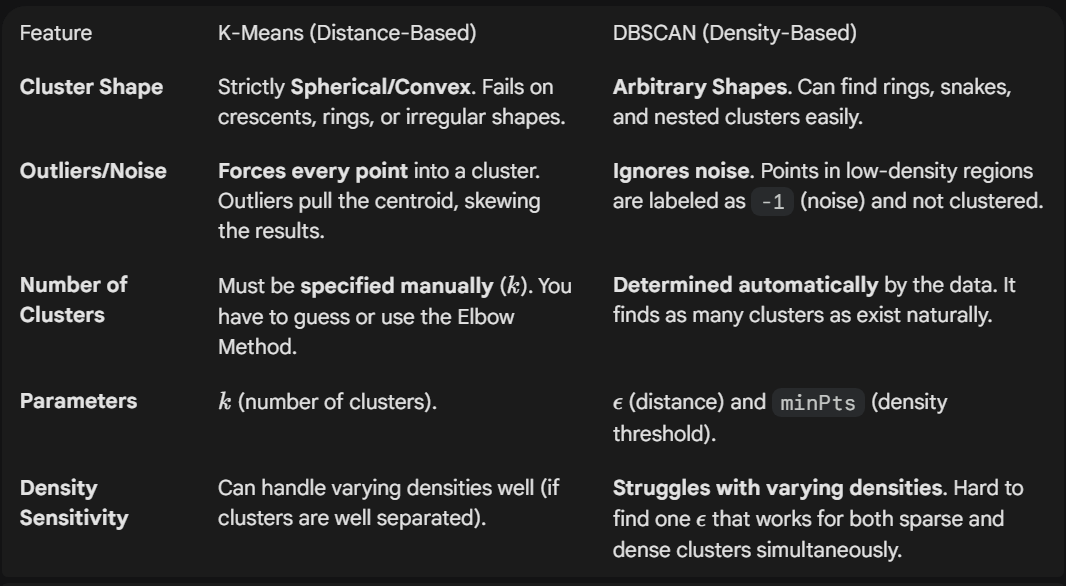

3. Deep Dive: Why "Distance-Based" is Different:
Technically, DBSCAN also uses distance (to check neighbors), but the objective is different.

- In K-Means (Global Optimization): The algorithm looks at the global picture. A point might be assigned to a cluster far away simply because the centroid is slightly closer than another, effectively "cutting" a continuous shape in half if it's not round.
    - Analogy: Dividing a crowd by drawing distinct circles on the floor and telling everyone to step into the nearest one.

- In DBSCAN (Local Connectivity): The algorithm looks locally. It only cares if point A is close to point B, and B is close to C. This "chaining" effect allows it to follow complex shapes.
    - Analogy: Asking people to hold hands if they are standing close enough. A long line of people holding hands forms one cluster, even if the line winds back and forth.

4. When to Use Which?
- Use K-Means when:
    - You know exactly how many segments you want (e.g., "I need 3 customer personas").
    - Your data is generally globular (blob-like) and equally sized.
    - You need speed (K-Means is generally faster on very large, simple datasets).

- Use DBSCAN when:
    - You do not know how many clusters exist.
    - The data has irregular structures (e.g., a map of road networks, biological cells).
    - Crucial: Your data is noisy. DBSCAN is excellent for outlier detection because it explicitly excludes anomalies.

- Visualizing the Difference Imagine a dataset shaped like a "Donut" (a ring of points with a hole in the middle).
    - K-Means will stick a centroid in the middle of the hole and slice the donut into pie pieces.
    - DBSCAN will recognize the ring as one single continuous cluster and identify the empty hole as noise

#### 1) Importing Necessary Libraries:

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

We are going to use 3 different datasets to visualize difference and use cases of different clustering methods.

In [2]:
blobs = pd.read_csv('cluster_blobs.csv')
moons = pd.read_csv('cluster_moons.csv')
circles = pd.read_csv('cluster_circles.csv')

##### 1) Blobs:

In [3]:
blobs.head()

,X1,X2
0,4.645333,6.822294
1,4.784032,6.422883
2,-5.851786,5.774331
3,-7.459592,6.456415
4,4.918911,6.961479


In [4]:
blobs.shape

(1500, 2)

In [5]:
blobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1500 non-null   float64
 1   X2      1500 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


In [6]:
blobs.describe()

,X1,X2
count,1500.000000,1500.000000
mean,-0.379401,2.141568
std,5.215288,6.308511
min,-10.503508,-9.498748
25%,-6.400126,-5.909959
50%,0.676300,5.709203
75%,4.620075,6.934017
max,9.370845,9.871754


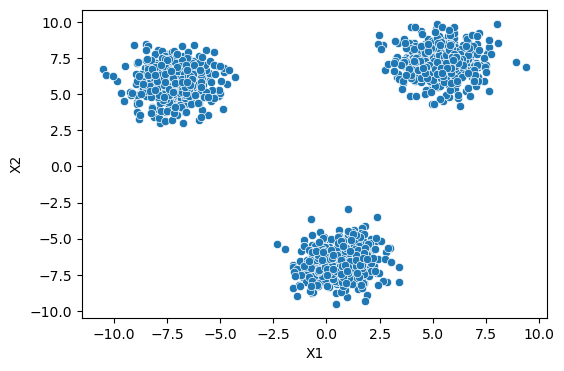

In [8]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= blobs, x= 'X1', y= 'X2')
plt.show()

##### 2) Moons:

In [9]:
moons.head()

,X1,X2
0,0.674362,-0.444625
1,1.547129,-0.239796
2,1.601930,-0.230792
3,0.014563,0.449752
4,1.503476,-0.389164


In [10]:
moons.shape

(1500, 2)

In [11]:
moons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1500 non-null   float64
 1   X2      1500 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


In [12]:
moons.describe()

,X1,X2
count,1500.000000,1500.000000
mean,0.498501,0.251743
std,0.868054,0.496365
min,-1.112339,-0.628397
25%,-0.036013,-0.202562
50%,0.497101,0.246369
75%,1.037322,0.718451
max,2.095098,1.119580


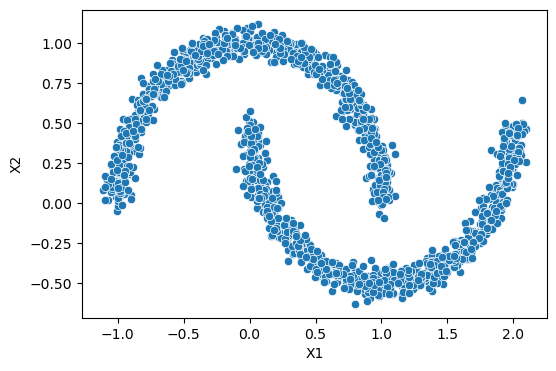

In [13]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= moons, x= 'X1', y= 'X2')
plt.show()

##### 3) Circles:

In [14]:
circles.head()

,X1,X2
0,-0.348677,0.010157
1,-0.176587,-0.954283
2,0.301703,-0.113045
3,-0.782889,-0.719468
4,-0.733280,-0.757354


In [15]:
circles.shape

(1500, 2)

In [16]:
circles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1500 non-null   float64
 1   X2      1500 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


In [17]:
circles.describe()

,X1,X2
count,1500.000000,1500.000000
mean,-0.001774,0.002696
std,0.521421,0.524787
min,-1.160050,-1.056985
25%,-0.286157,-0.286841
50%,-0.008298,0.003268
75%,0.285604,0.294371
max,1.093118,1.144814


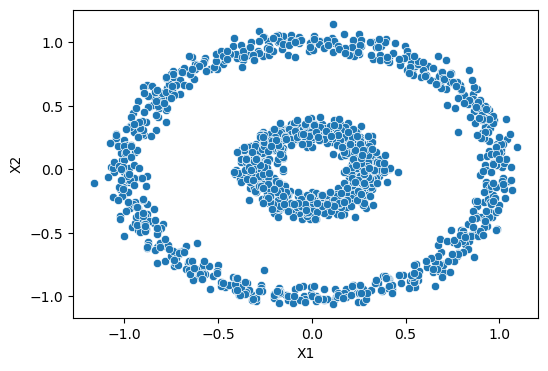

In [19]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= circles, x= 'X1', y= 'X2')
plt.show()

#### 3) Function for Visualizing Clusters:

In [20]:
def visualize_clusters(model, data):
    '''
    Function to visualize Clusters on 2D data (data with 2 features)
    Parameters:
    model: Clustering Model Instance.
    data: 2D Data on which to fit Clustering Model.
    '''

    clusters = model.fit_predict(data)
    plt.figure(figsize= (6,4), dpi= 150)
    sns.scatterplot(data= data, x= "X1", y="X2", hue= clusters, palette= "dark")
    plt.show()

#### 4) Distance Based and Density Based Clustering on Blobs Dataset:

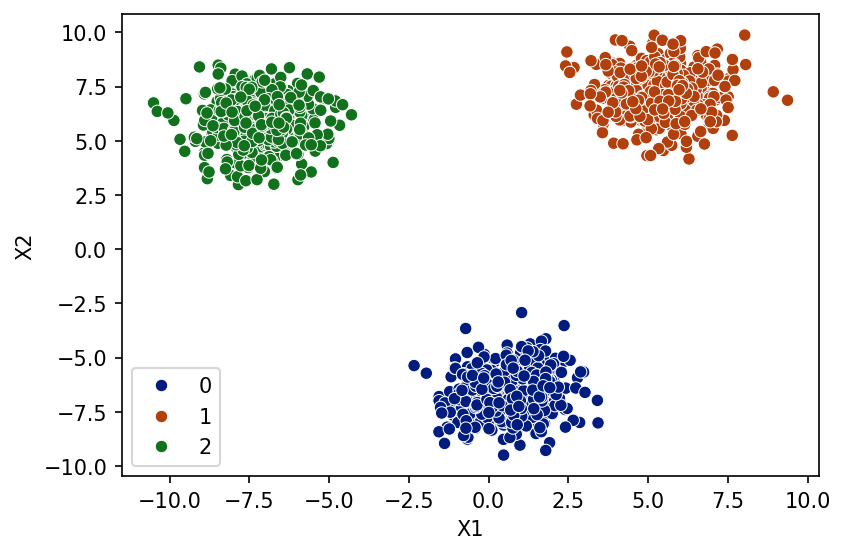

In [23]:
#KMeans Clustering:

kmc = KMeans(n_clusters= 3) #KMeans CLuster Instance
visualize_clusters(kmc, blobs)

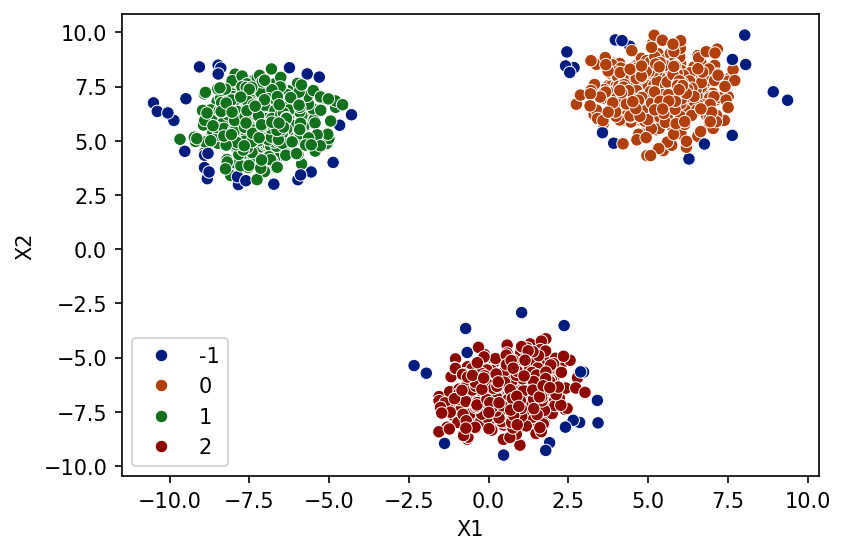

In [24]:
#DBSCAN Clustering:

dbscan = DBSCAN(eps= 0.5) #DBSCAN CLuster Instance
visualize_clusters(dbscan, blobs)

- -1 is not a cluster number here.
- -1 in DBSCAN represents points that are considered Outliers.
- We can Increase or Decrease Outliers by changing "eps" value.

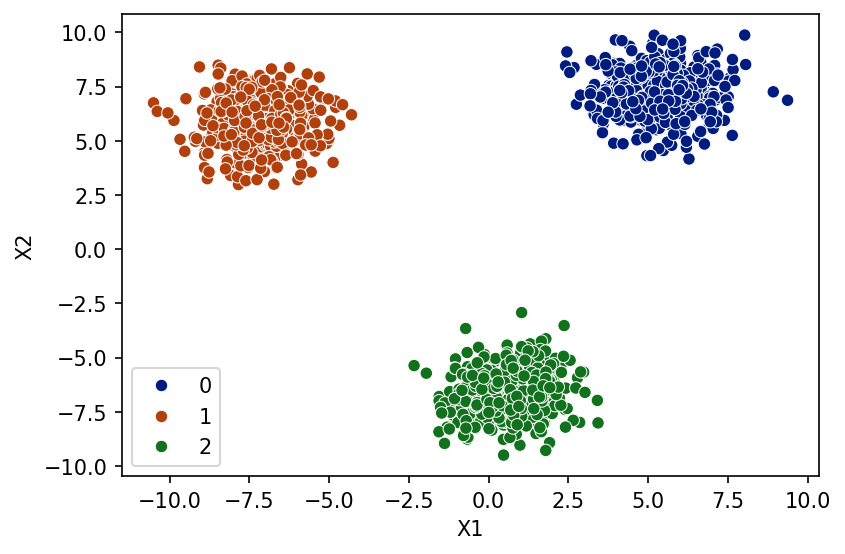

In [27]:
#DBSCAN Clustering:

dbscan = DBSCAN(eps= 1.5) #DBSCAN CLuster Instance
visualize_clusters(dbscan, blobs)

#### 5) Distance Based and Density Based Clustering on Moons Dataset:

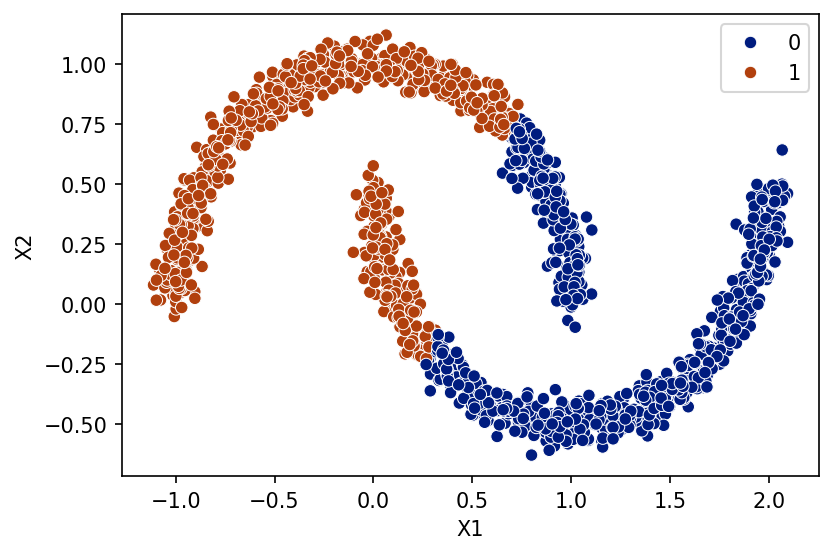

In [26]:
#KMeans Clustering:

kmc = KMeans(n_clusters= 2) #KMeans CLuster Instance
visualize_clusters(kmc, moons)

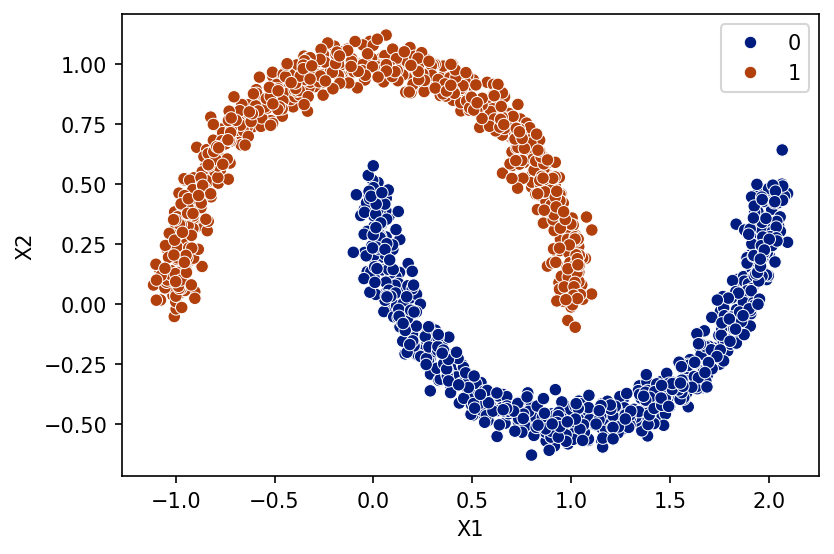

In [28]:
#DBSCAN Clustering:

dbscan = DBSCAN(eps= 0.2) #DBSCAN CLuster Instance
visualize_clusters(dbscan, moons)

#### 6) Distance Based and Density Based Clustering on Circles Dataset:

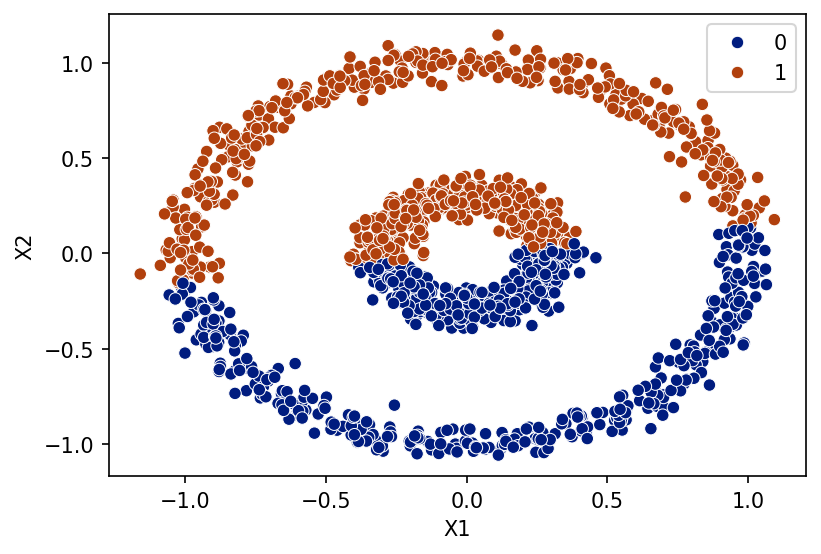

In [29]:
#KMeans Clustering:

kmc = KMeans(n_clusters= 2) #KMeans CLuster Instance
visualize_clusters(kmc, circles)

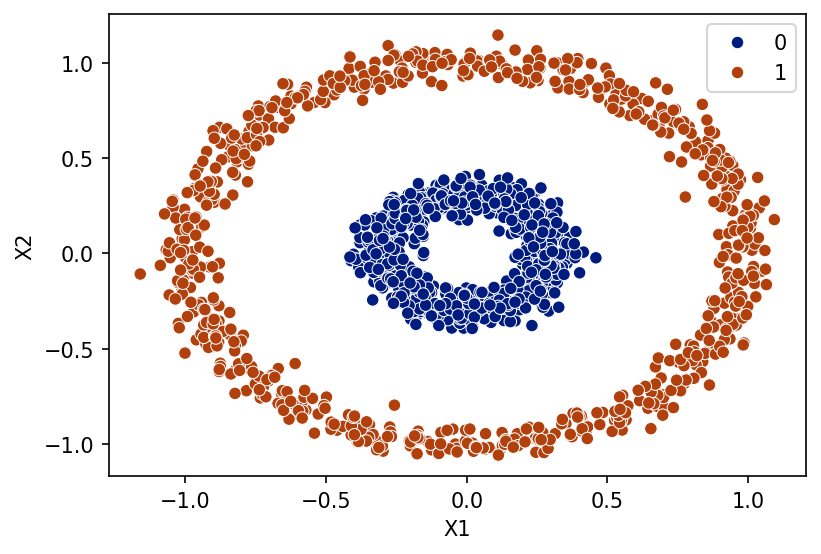

In [30]:
#DBSCAN Clustering:

dbscan = DBSCAN(eps= 0.2) #DBSCAN CLuster Instance
visualize_clusters(dbscan, circles)